In [2]:
import pandas as pd
import numpy as np
from numpy.linalg import inv, norm, svd, pinv
import matplotlib.pyplot as plt

I will first import the dataset then clean it.

In [3]:
df = pd.read_csv(r"C:\Users\85251\Downloads\UCI_Credit_Card.csv\UCI_Credit_Card.csv") # input the csv dataset
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [4]:
df.isnull().sum() # check whether there are missing values

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [5]:
pay_list = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
for i in pay_list:
    print(df[i].value_counts()) # See the categorical distribution of each payment delay columns

PAY_0
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9
Name: count, dtype: int64
PAY_2
 0    15730
-1     6050
 2     3927
-2     3782
 3      326
 4       99
 1       28
 5       25
 7       20
 6       12
 8        1
Name: count, dtype: int64
PAY_3
 0    15764
-1     5938
-2     4085
 2     3819
 3      240
 4       76
 7       27
 6       23
 5       21
 1        4
 8        3
Name: count, dtype: int64
PAY_4
 0    16455
-1     5687
-2     4348
 2     3159
 3      180
 4       69
 7       58
 5       35
 6        5
 1        2
 8        2
Name: count, dtype: int64
PAY_5
 0    16947
-1     5539
-2     4546
 2     2626
 3      178
 4       84
 7       58
 5       17
 6        4
 8        1
Name: count, dtype: int64
PAY_6
 0    16286
-1     5740
-2     4895
 2     2766
 3      184
 4       49
 7       46
 6       19
 5       13
 8        2
Name: count, dtype: int64


In [6]:
df['EDUCATION'].value_counts() # see the distribution of education

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

In [7]:
df['SEX'] = df['SEX'].map({1:0, 2:1}) # adjust the binary label
df = df[~df['EDUCATION'].isin([0, 5, 6])] # ignore education = 0, 5, 6 as I don't have information of what level they are
df['MARRIAGE'] = df['MARRIAGE'].map({1:0, 2:1, 3:2})
for i in pay_list:
    df[i] = df[i].replace({-2:0, -1:0}) # I also don't know what -2 and -1 mean, so I set them to zero, which represents that the payment is on time
    # map will return other values to be NA, while replace ignore other values
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,1,2,0.0,24,2,2,0,0,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,1,2,1.0,26,0,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,1,2,1.0,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,1,2,0.0,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,0,2,0.0,57,0,0,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


I am going to build a regression model, regress the credit card limit against the sex, education, marriage and age of the holder.

In [46]:
X_reg = df[['SEX', 'EDUCATION', 'MARRIAGE', 'AGE']]
y_reg = df['LIMIT_BAL']
X_reg = pd.get_dummies(X_reg, columns = ['EDUCATION', 'MARRIAGE'], dtype = float, drop_first=True) # Transform categorical variable to binary variables
X_reg.head()

,SEX,AGE,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_1.0,MARRIAGE_2.0
0,1,24,1.0,0.0,0.0,0.0,0.0
1,1,26,1.0,0.0,0.0,1.0,0.0
2,1,34,1.0,0.0,0.0,1.0,0.0
3,1,37,1.0,0.0,0.0,0.0,0.0
4,0,57,1.0,0.0,0.0,0.0,0.0


In [47]:
from sklearn.model_selection import train_test_split 
X_reg_train,X_reg_test,y_reg_train,y_reg_test = train_test_split(X_reg, y_reg) # split the data into training set and testing set
from sklearn.preprocessing import StandardScaler
X_reg_1_Scaler = StandardScaler()
X_reg_train[['AGE']]= X_reg_1_Scaler.fit_transform(X_reg_train[['AGE']]) # Scale the only numerical variable
X_reg_test[['AGE']]= X_reg_1_Scaler.transform(X_reg_test[['AGE']])
X_reg_test.head()

,SEX,AGE,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_1.0,MARRIAGE_2.0
19522,1,-0.804510,0.0,0.0,0.0,1.0,0.0
2803,0,-0.804510,0.0,0.0,0.0,1.0,0.0
10057,1,2.778955,0.0,1.0,0.0,0.0,0.0
9634,1,-0.152971,0.0,0.0,0.0,1.0,0.0
12793,0,0.172798,0.0,0.0,0.0,0.0,0.0


In [13]:
def R_adjusted(y_pred, y, n, m): # adjusted R-squared formula
    y_bar = np.mean(y)
    return 1-(np.sum((y-y_pred)**2)/(np.sum((y-y_bar)**2)))/(1-n/(m-1))

I first tried OLS regression by normal equation. It took 0.0s. The training and testing adjusted R-squared are 0.1185 and 0.1115 respectively.

In [11]:
X_reg_train_1 = np.hstack([np.ones(X_reg_train.shape[0]).reshape(-1, 1), X_reg_train]) # X
X_reg_test_1 = np.hstack([np.ones(X_reg_test.shape[0]).reshape(-1, 1), X_reg_test])
theta_reg_1 = inv(X_reg_train_1.T@X_reg_train_1)@X_reg_train_1.T@y_reg_train # inv(X.T@X)@X.T@y
print(theta_reg_1)
y_reg_pred_train_1 = X_reg_train_1@theta_reg_1 # prediction
y_reg_pred_test_1 = X_reg_test_1@theta_reg_1
R_reg_1_train = R_adjusted(y_reg_pred_train_1, y_reg_train, X_reg_train.shape[1], X_reg_train.shape[0])
R_reg_1_test = R_adjusted(y_reg_pred_test_1, y_reg_test, X_reg_test.shape[1], X_reg_test.shape[0])
print(R_reg_1_train)
print(R_reg_1_test)

[ 222802.52530873   11696.82799024   21389.82964606  -71574.01533259
 -104782.53754775   11208.00225031  -18434.23934558  -76609.6695778 ]
0.11851565479199822
0.11152030412254976


Then, I tried Gradient Descent Method for OLS with initial parameter of zero vector, step size 0.1 and tolerance 0.0001. It took 10.2 second and 29171 loops. The training and testing adjusted R-squared are also 0.1185 and 0.1115 respectively.

In [12]:
X_reg_train_2 = X_reg_train_1
X_reg_test_2 = X_reg_test_1
step_1 = 0.1 # step size
tol = 1e-4 # tolerance
theta_reg_2 = np.zeros(X_reg_train_2.shape[1]) # initial theta as zero vector
g = ((X_reg_train_2.T@X_reg_train_2)@theta_reg_2 - X_reg_train_2.T@y_reg_train)/X_reg_train_2.shape[0] # gradient vector
count = 0
while norm(g) > tol: # run until norm of gradient less than tolerance
    theta_reg_2 = theta_reg_2 - step_1 * g
    g = ((X_reg_train_2.T@X_reg_train_2)@theta_reg_2 - X_reg_train_2.T@y_reg_train)/X_reg_train_2.shape[0]
    count = count + 1
print(theta_reg_2)
print(count)
y_reg_pred_train_2 = X_reg_train_2@theta_reg_2
y_reg_pred_test_2 = X_reg_test_2@theta_reg_2
R_reg_2_train = R_adjusted(y_reg_pred_train_2, y_reg_train, X_reg_train.shape[1], X_reg_train.shape[0])
R_reg_2_test = R_adjusted(y_reg_pred_test_2, y_reg_test, X_reg_test.shape[1], X_reg_test.shape[0])
print(R_reg_2_train)
print(R_reg_2_test)

[ 222802.52562054   11696.82802381   21389.82963703  -71574.01563713
 -104782.53786022   11207.97723887  -18434.23941374  -76609.66935924]
31321
0.11851565479199799
0.11152030428281745


Then, I tried Steepest Descent Method for OLS with initial parameter of zero vector and tolerance 0.0001. It took 0.8 second and 2876 loops, much better than Gradient Descent Method. The R-squared are also 0.1185 and 0.1115, the same model accuracy as the previous two models.

In [13]:
X_reg_train_3 = X_reg_train_1
X_reg_test_3 = X_reg_test_1
tol = 1e-4 # tolerance
theta_reg_3 = np.zeros(X_reg_train_3.shape[1])
g = ((X_reg_train_3.T@X_reg_train_3)@theta_reg_3 - X_reg_train_3.T@y_reg_train)/X_reg_train_3.shape[0]
count = 0
while norm(g) > tol:
    theta_reg_3 = theta_reg_3 - (g.T@g)/(g.T@X_reg_train_3.T@X_reg_train_3@g/X_reg_train.shape[0]) * g # different iteration coefficient
    g = ((X_reg_train_3.T@X_reg_train_3)@theta_reg_3 - X_reg_train_3.T@y_reg_train)/X_reg_train_3.shape[0]
    count = count + 1
print(theta_reg_3)
print(count)
y_reg_pred_train_3 = X_reg_train_3@theta_reg_3
y_reg_pred_test_3 = X_reg_test_3@theta_reg_3
R_reg_3_train = R_adjusted(y_reg_pred_train_3, y_reg_train, X_reg_train.shape[1], X_reg_train.shape[0])
R_reg_3_test = R_adjusted(y_reg_pred_test_3, y_reg_test, X_reg_test.shape[1], X_reg_test.shape[0])
print(R_reg_3_train)
print(R_reg_3_test)

[ 222802.52552976   11696.82800182   21389.82964276  -71574.01558005
 -104782.53779306   11207.98284506  -18434.23941144  -76609.66940842]
3108
0.11851565479199799
0.11152030425809178


After that, I tried the sklearn package for linear regression, which used the least‑squares solver based on SVD. It took 2.3s for the first time, due to package importing. Hence, if you have the code for normal equations, it will be slightly quicker than using package. The R-squared are also 0.1185 and 0.1115, the same as the previous models. 

In [14]:
from sklearn.linear_model import LinearRegression 
model_reg_1 = LinearRegression() 
model_reg_1.fit(X_reg_train, y_reg_train) 
m_1 = model_reg_1.coef_ 
c_1 = model_reg_1.intercept_ 
print(m_1)
print(c_1)
y_reg_pred_train_4 = model_reg_1.predict(X_reg_train)
y_reg_pred_test_4 = model_reg_1.predict(X_reg_test)
R_reg_4_train = R_adjusted(y_reg_pred_train_4, y_reg_train, X_reg_train.shape[1], X_reg_train.shape[0])
R_reg_4_test = R_adjusted(y_reg_pred_test_4, y_reg_test, X_reg_test.shape[1], X_reg_test.shape[0])
print(R_reg_4_train)
print(R_reg_4_test)

[  11696.82799024   21389.82964606  -71574.01533259 -104782.53754775
   11208.00225031  -18434.23934558  -76609.6695778 ]
222802.52530872775
0.11851565479199799
0.11152030412254998


Next, I tried the sklearn package for linear regression, with Polynomial transformation on age. It took 0s to run. The adjusted R-squared has improved to 0.1512 and 0.1401, which means that the polynomial model is more suitable.

In [15]:
from sklearn.preprocessing import PolynomialFeatures
qua = PolynomialFeatures(degree = 2, include_bias = False) # set the degree
X_reg_train_5 = qua.fit_transform(X_reg_train[['AGE']]) # transform the X['AGE']
X_reg_train_5 = np.hstack([X_reg_train_5, X_reg_train.drop(columns=['AGE'], inplace = False)]) # combine with other non-numeric columns
X_reg_test_5 = qua.transform(X_reg_test[['AGE']])
X_reg_test_5 = np.hstack([X_reg_test_5, X_reg_test.drop(columns=['AGE'], inplace = False)])
model_reg_2 = LinearRegression() # fit the regression package normally
model_reg_2.fit(X_reg_train_5, y_reg_train)
m_2 = model_reg_2.coef_ 
c_2 = model_reg_2.intercept_ 
print(m_2)
print(c_2)
y_reg_pred_train_5 = model_reg_2.predict(X_reg_train_5)
y_reg_pred_test_5 = model_reg_2.predict(X_reg_test_5)
R_reg_5_train = R_adjusted(y_reg_pred_train_5, y_reg_train, X_reg_train_5.shape[1] - 1, X_reg_train.shape[0])
R_reg_5_test = R_adjusted(y_reg_pred_test_5, y_reg_test, X_reg_test_5.shape[1] - 1, X_reg_test.shape[0])
print(R_reg_5_train)
print(R_reg_5_test)

[ 37890.39938416 -19564.50514226  13278.16993999 -68478.88652437
 -98357.99522299  11447.87913535  -7375.96604018 -71565.38937534]
232932.18821057782
0.15120670934510672
0.14014632286385853


Then, I used Grid Search Cross Validation method for Polynomial Ridge Regression. I have tested polynomial degree from 1 to 5 and multiple regularization penalties. After 2.5s, we have chosen a quartic polynomial and alpha equal to 10. The adjusted R-squared further improve to 0.1770 and 0.1610, which is the best among the regression models, but the grid search method really took some time.

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.compose import ColumnTransformer
num_cols = ['AGE']
bin_cols = X_reg_train.columns.difference(num_cols).tolist() # get the numeric and binary columns name
preprocess = ColumnTransformer(
    transformers=[
        ('poly_age', PolynomialFeatures(include_bias=False), num_cols), # only pass the numeric columns to polynomial transformer
        ('bin', 'passthrough', bin_cols)
    ]
)
pipe = Pipeline([ # write the pipeline
    ('pre', preprocess),
    ('ridge', Ridge())
])

param_grid = { # grid of our hyperparameters and degree of complexity
    'pre__poly_age__degree': [1, 2, 3, 4, 5],
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}
grid_search = GridSearchCV(pipe, param_grid, cv=5) 
grid_search.fit(X_reg_train, y_reg_train)
best_model = grid_search.best_estimator_ # get the best model out
m_3 = best_model.named_steps['ridge'].coef_
c_3 = best_model.named_steps['ridge'].intercept_
print(grid_search.best_params_)
print(m_3)
print(c_3)
y_reg_pred_train_6 = best_model.predict(X_reg_train)
y_reg_pred_test_6 = best_model.predict(X_reg_test)
R_reg_6_train = R_adjusted(y_reg_pred_train_6, y_reg_train, best_model.named_steps['pre'].fit_transform(X_reg_train).shape[1] # this is the number of features
, X_reg_train.shape[0])
R_reg_6_test = R_adjusted(y_reg_pred_test_6, y_reg_test, best_model.named_steps['pre'].fit_transform(X_reg_test).shape[1], X_reg_test.shape[0])
print(R_reg_6_train)
print(R_reg_6_test)

{'pre__poly_age__degree': 5, 'ridge__alpha': 1}
[  6846.74112759 -36223.42523054  18920.17283814  -3337.36757329
    247.7801188  -63604.77622281 -91790.50108052  12333.59268602
  -8120.54531188 -67163.06611459  14599.3042476 ]
240571.91716547593
0.17698666068959767
0.16095391392851


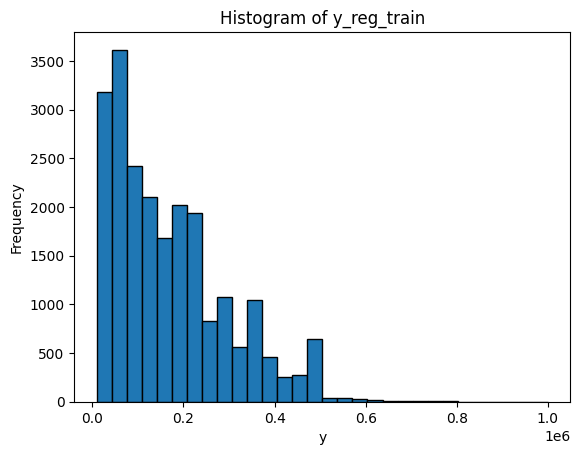

In [ ]:
plt.hist(y_reg_train, bins=30, edgecolor='black')
plt.xlabel('y')
plt.ylabel('Frequency')
plt.title('Histogram of y_reg_train')
plt.show() # Since y is right skewed, we applied logarithmic transformation
# if left skewed, use log(c-x) or square to remove negative data

In [ ]:
def g(x): # activation function
    return np.log(1+np.exp(x))
def h(x): # derivative of activation function
    return np.exp(x)/(1+np.exp(x))
eta = 0.1

In [19]:
w80 = np.random.rand()
w81 = np.random.rand()
w82 = np.random.rand()
w83 = np.random.rand()
w84 = np.random.rand()
w85 = np.random.rand()
w86 = np.random.rand()
w87 = np.random.rand()
w90 = np.random.rand()
w91 = np.random.rand()
w92 = np.random.rand()
w93 = np.random.rand()
w94 = np.random.rand()
w95 = np.random.rand()
w96 = np.random.rand()
w97 = np.random.rand()
w100 = np.random.rand()
w108 = np.random.rand()
w109 = np.random.rand()

Next, I tried a man-made neural network code, solved by Stochastic Gradient Descent method. There is 1 hidden layer with 2 neurons. I took step size to be 0.1 and iterate for 10 million times (input one data counts one). The activation function is $h(x) = \log(1 + e^{x})$. It took 4 minutes to run. The adjusted R-squared of training and testing dataset are 0.1238 and 0.1108 respectively, which are close to the linear regression models (without polynomial or ridge features) above. Hence, using complex neural network with smooth approximation of ReLU function is not useful in this case.

In [20]:
X_reg_train_neural = np.array(X_reg_train)
y_reg_train_neural = np.log(np.array(y_reg_train))
for i in range(10000000):
    j = np.mod(i, X_reg_train.shape[0])    
    
    # forward propagation
    x1 = X_reg_train_neural[j,0] 
    x2 = X_reg_train_neural[j,1]
    x3 = X_reg_train_neural[j,2]
    x4 = X_reg_train_neural[j,3]
    x5 = X_reg_train_neural[j,4]  
    x6 = X_reg_train_neural[j,5]  
    x7 = X_reg_train_neural[j,6]     
    l8 = x1*w81+x2*w82+x3*w83+x4*w84+x5*w85+x6*w86+x7*w87+w80
    x8 = g(l8)
    l9 = x1*w91+x2*w92+x3*w93+x4*w94+x5*w95+x6*w96+x7*w97+w90
    x9 = g(l9)
    l10 = x8*w108+x9*w109+w100  
    x10 = l10
    
    # backpropagation
    # delta
    d10 = y_reg_train_neural[j]-x10
    d9 = h(l9)*(1-h(l9))*(d10*w109)     
    d8 = h(l8)*(1-h(l8))*(d10*w108)
    
    # update   
    w81 = w81+eta*d8*x1
    w82 = w82+eta*d8*x2
    w83 = w83+eta*d8*x3
    w84 = w84+eta*d8*x4
    w85 = w85+eta*d8*x5
    w86 = w86+eta*d8*x6
    w87 = w87+eta*d8*x7
    w80 = w80+eta*d8   

    w91 = w91+eta*d9*x1
    w92 = w92+eta*d9*x2
    w93 = w93+eta*d9*x3
    w94 = w94+eta*d9*x4
    w95 = w95+eta*d9*x5
    w96 = w96+eta*d9*x6
    w97 = w97+eta*d9*x7
    w90 = w90+eta*d9  

    w108 = w108+eta*d10*x8
    w109 = w109+eta*d10*x9
    w100 = w100+eta*d10

In [21]:
y_reg_pred_train_7 = np.zeros(X_reg_train.shape[0])
for j in range(X_reg_train.shape[0]):    
    x1 = X_reg_train_neural[j,0] 
    x2 = X_reg_train_neural[j,1]
    x3 = X_reg_train_neural[j,2]
    x4 = X_reg_train_neural[j,3]
    x5 = X_reg_train_neural[j,4]  
    x6 = X_reg_train_neural[j,5]  
    x7 = X_reg_train_neural[j,6]     
    l8 = x1*w81+x2*w82+x3*w83+x4*w84+x5*w85+x6*w86+x7*w87+w80
    x8 = g(l8)
    l9 = x1*w91+x2*w92+x3*w93+x4*w94+x5*w95+x6*w96+x7*w97+w90
    x9 = g(l9)
    l10 = x8*w108+x9*w109+w100  
    y_reg_pred_train_7[j] = np.exp(l10)

X_reg_test_neural = np.array(X_reg_test)
y_reg_pred_test_7 = np.zeros(X_reg_test.shape[0])
for j in range(X_reg_test.shape[0]):    
    x1 = X_reg_test_neural[j,0] 
    x2 = X_reg_test_neural[j,1]
    x3 = X_reg_test_neural[j,2]
    x4 = X_reg_test_neural[j,3]
    x5 = X_reg_test_neural[j,4]  
    x6 = X_reg_test_neural[j,5]  
    x7 = X_reg_test_neural[j,6]     
    l8 = x1*w81+x2*w82+x3*w83+x4*w84+x5*w85+x6*w86+x7*w87+w80
    x8 = g(l8)
    l9 = x1*w91+x2*w92+x3*w93+x4*w94+x5*w95+x6*w96+x7*w97+w90
    x9 = g(l9)
    l10 = x8*w108+x9*w109+w100  
    y_reg_pred_test_7[j] = np.exp(l10)

R_reg_7_train = R_adjusted(y_reg_pred_train_7, y_reg_train, X_reg_train.shape[1], X_reg_train.shape[0])
R_reg_7_test = R_adjusted(y_reg_pred_test_7, y_reg_test, X_reg_train.shape[1], X_reg_test.shape[0])
print(R_reg_7_train)
print(R_reg_7_test)

0.12384055552205964
0.11078978073002532


After that, I tried the MLPRegressor, which used sgd and the model is similiar solving method to my written code. But I can build a more complex structure here. I took 128 and 64 as the hidden layer sizes; relu as the activation function; regularization penalty equal to 0.1; and maximum iterations of 10000. It took only 9.7s to run the code. The adjusted R-squared of training and testing dataset are 0.1434 snd 0.1236 respectively. It performs better and quicker than the simple hand-written code of neural network, and more accurate than simple linear regression. But if we do a polynomial transformation with ridge regression, the model will be less complex but more accurate. 

In [ ]:
from sklearn.neural_network import MLPRegressor
clf = MLPRegressor(hidden_layer_sizes=[128, 64], activation='relu', solver='sgd', alpha = 0.0001, max_iter=10000) # alpha is L2 regularization strength
clf.fit(X_reg_train_neural, y_reg_train_neural)
y_reg_pred_train_8 = np.exp(clf.predict(X_reg_train_neural))
y_reg_pred_test_8 = np.exp(clf.predict(X_reg_test_neural))
R_reg_8_train = R_adjusted(y_reg_pred_train_8, y_reg_train, X_reg_train.shape[1], X_reg_train.shape[0])
R_reg_8_test = R_adjusted(y_reg_pred_test_8, y_reg_test, X_reg_train.shape[1], X_reg_test.shape[0])
print(R_reg_8_train)
print(R_reg_8_test)

0.14338172196485166
0.12358436601448841


In [36]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Lastly, I tried xgboost, which is an ensemble tree method that I lack of understanding. It took 1.7s to run. The adjusted R-squared are 0.1126 and 0.0873, worse than other models.

In [42]:
import xgboost as xgb
from xgboost import XGBRegressor

xgb_model = XGBRegressor(objective='reg:squarederror',  
    n_estimators=300,             # Number of trees
    learning_rate=0.05,           # step size shrinkage
    max_depth=4,                  # tree depth
    reg_lambda=1.0,               # L2 regularization
    random_state=0)

xgb_model.fit(X_reg_train_neural, y_reg_train_neural)
y_reg_pred_train_9 = np.exp(xgb_model.predict(X_reg_train_neural))
y_reg_pred_test_9 = np.exp(xgb_model.predict(X_reg_test_neural))
R_reg_9_train = R_adjusted(y_reg_pred_train_9, y_reg_train, X_reg_train.shape[1], X_reg_train.shape[0])
R_reg_9_test = R_adjusted(y_reg_pred_test_9, y_reg_test, X_reg_train.shape[1], X_reg_test.shape[0])
print(R_reg_9_train)
print(R_reg_9_test)

0.11256628821656323
0.08731881906431027


In conclusion, neural network and xgboost require more adjustment on activation function, layers size and other hyperparameters. We should build ridge regression model with polynomial transformation and grid search to speed up and enhance the accuracy.

Here comes to the second part of analysis, I have done a classification of default in next month against all other variables except id. And I have also applied get dummies on education and marriage as they are the only categorical variables except the payment status, which the number represent the number of months lag is linear to the real situation.

In [39]:
X_cl = df.drop(columns=['ID', 'default.payment.next.month'])
y_cl = df['default.payment.next.month']
X_cl = pd.get_dummies(X_cl, columns = ['EDUCATION', 'MARRIAGE'], dtype = float, drop_first=True)
X_cl.head()

,LIMIT_BAL,SEX,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,...,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_1.0,MARRIAGE_2.0
0,20000.0,1,24,2,2,0,0,0,0,3913.0,...,689.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,120000.0,1,26,0,2,0,0,0,2,2682.0,...,1000.0,1000.0,1000.0,0.0,2000.0,1.0,0.0,0.0,1.0,0.0
2,90000.0,1,34,0,0,0,0,0,0,29239.0,...,1500.0,1000.0,1000.0,1000.0,5000.0,1.0,0.0,0.0,1.0,0.0
3,50000.0,1,37,0,0,0,0,0,0,46990.0,...,2019.0,1200.0,1100.0,1069.0,1000.0,1.0,0.0,0.0,0.0,0.0
4,50000.0,0,57,0,0,0,0,0,0,8617.0,...,36681.0,10000.0,9000.0,689.0,679.0,1.0,0.0,0.0,0.0,0.0


In [48]:
X_cl_train,X_cl_test,y_cl_train,y_cl_test = train_test_split(X_cl, y_cl) 
X_cl_1_Scaler = StandardScaler()
numer_cols = ['AGE', 'LIMIT_BAL', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
X_cl_train[numer_cols]= X_cl_1_Scaler.fit_transform(X_cl_train[numer_cols]) 
X_cl_test[numer_cols]= X_cl_1_Scaler.transform(X_cl_test[numer_cols])
X_cl_test.head()

,LIMIT_BAL,SEX,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,...,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_1.0,MARRIAGE_2.0
4561,0.405387,1,0.276566,-0.467801,-0.402102,-0.385439,-0.342051,-0.310032,-0.322107,-0.631724,...,-0.117671,-0.233823,-0.176208,-0.213819,-0.291141,0.0,0.0,0.0,0.0,0.0
8793,1.715339,1,1.909344,-0.467801,-0.402102,-0.385439,-0.342051,-0.310032,-0.322107,-0.653915,...,1.974882,-0.176686,-0.278992,-0.309819,-0.291141,0.0,1.0,0.0,0.0,0.0
17388,-0.288117,1,0.929677,2.145374,-0.402102,-0.385439,2.263725,2.459210,2.437513,0.297381,...,0.022849,-0.109489,-0.081039,-0.105020,-0.103411,1.0,0.0,0.0,1.0,0.0
9939,0.020107,0,-0.594249,-0.467801,-0.402102,-0.385439,-0.342051,-0.310032,-0.322107,-0.686886,...,-0.212744,-0.279036,-0.276707,-0.273595,-0.267476,1.0,0.0,0.0,0.0,0.0
516,-0.750453,0,-0.376545,-0.467801,-0.402102,-0.385439,-0.342051,-0.310032,-0.322107,0.250173,...,-0.105627,-0.142833,-0.128624,-0.133820,0.021743,0.0,1.0,0.0,0.0,0.0


For the logistic response function, I have applied a clip function to prevent overflow to NaN. It should not affect the result significantly as $1/(1 + e^{500})$ and $1/(1 + e^{-500})$ are very close to 0 and 1 respectively. 

In [49]:
def h_cl(theta, X):
    z = X @ theta
    z = np.clip(z, -500, 500)  # Prevent overflow
    return 1 / (1 + np.exp(-z))

Then, I have analysed the multicollinearity of explanatory variables and drop the highly correlated features to avoid inversing singular Hessian matrix later.

In [50]:
# Find high correlations
corr_matrix = pd.DataFrame(X_cl_train).corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)) # get the upper triangular part only
print(upper_tri)
to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)] # drop the latter column with any correlation greater than 0.95 (older information will be removed)
print(to_drop)

# Drop them
X_cl_train_clean = X_cl_train.drop(columns=to_drop)
X_cl_test_clean = X_cl_test.drop(columns=to_drop)

              LIMIT_BAL       SEX       AGE     PAY_0     PAY_2     PAY_3  \
LIMIT_BAL           NaN  0.026916  0.141294  0.168369  0.195103  0.188944   
SEX                 NaN       NaN  0.090152  0.038773  0.051760  0.045038   
AGE                 NaN       NaN       NaN  0.000966  0.008848  0.013949   
PAY_0               NaN       NaN       NaN       NaN  0.702871  0.519870   
PAY_2               NaN       NaN       NaN       NaN       NaN  0.662734   
PAY_3               NaN       NaN       NaN       NaN       NaN       NaN   
PAY_4               NaN       NaN       NaN       NaN       NaN       NaN   
PAY_5               NaN       NaN       NaN       NaN       NaN       NaN   
PAY_6               NaN       NaN       NaN       NaN       NaN       NaN   
BILL_AMT1           NaN       NaN       NaN       NaN       NaN       NaN   
BILL_AMT2           NaN       NaN       NaN       NaN       NaN       NaN   
BILL_AMT3           NaN       NaN       NaN       NaN       NaN       NaN   

To evaluate the performance of models, I used recall the most as we concerned on the proportion of predicted non-default but actually default. Meanwhile, precision was used as a constraint to maximize recall. Moreover, the deviation of actual default loss and expected default loss is also my concern. In some cases, training performance was calculated but I pay more attention on the testing performance.

Firstly, I used the most traditional method to build the model by Newton Method. The recall and loss deviation metrics are then calculated without using packages. It took only 0.1s and only ran for 6 loops. The recall values are around 0.34 at threshold of 0.5. The tranining deviation of default loss is very close to zero, while the testing deviation is 2.9 Million.

In [52]:
X_cl_train_np = np.hstack([np.ones(X_cl_train_clean.shape[0]).reshape(-1, 1), np.array(X_cl_train_clean)]) # Construct the matrix X
X_cl_test_np = np.hstack([np.ones(X_cl_test_clean.shape[0]).reshape(-1, 1), np.array(X_cl_test_clean)])
theta_cl_1 = np.zeros(X_cl_train_np.shape[1]) # initial by zero vector
te = 1e-6  # tolerance
max_iter = 100 # maximum iterations
count = 0 # counter
h = h_cl(theta_cl_1, X_cl_train_np) # predicted probability
grad_J = (1/X_cl_train_clean.shape[0]) * X_cl_train_np.T @ (h - y_cl_train) # gradient of cost function
while norm(grad_J) > te and count < max_iter: # iterative conditions
    h = h_cl(theta_cl_1, X_cl_train_np)
    grad_J = (1/X_cl_train_clean.shape[0]) * X_cl_train_np.T @ (h - y_cl_train)
    sr = np.sqrt(h * (1 - h))
    S = np.tile(sr[:, np.newaxis], (1, X_cl_train_np.shape[1]))
    S = S * X_cl_train_np
    H = (1/X_cl_train_clean.shape[0]) * S.T @ S # Hessian matrix
    delta = inv(H) @ grad_J # require inverse
    theta_cl_1 = theta_cl_1 - delta
    count += 1
print(norm(grad_J))
print(count)
print(theta_cl_1)
y_cl_pred_train_1 = (h_cl(theta_cl_1, X_cl_train_np) >= 0.5)
y_cl_pred_test_1 = (h_cl(theta_cl_1, X_cl_test_np) >= 0.5)
tp_train_1 = np.sum((y_cl_pred_train_1 == 1) & (y_cl_train == 1))
tp_test_1 = np.sum((y_cl_pred_test_1 == 1) & (y_cl_test == 1))
fp_train_1 = np.sum((y_cl_pred_train_1 == 1) & (y_cl_train == 0))
fp_test_1 = np.sum((y_cl_pred_test_1 == 1) & (y_cl_test == 0))
tn_train_1 = np.sum((y_cl_pred_train_1 == 0) & (y_cl_train == 0))
tn_test_1 = np.sum((y_cl_pred_test_1 == 0) & (y_cl_test == 0))
fn_train_1 = np.sum((y_cl_pred_train_1 == 0) & (y_cl_train == 1))
fn_test_1 = np.sum((y_cl_pred_test_1 == 0) & (y_cl_test == 1))
recall_train_1 = tp_train_1/(tp_train_1 + fn_train_1)
recall_test_1 = tp_test_1/(tp_test_1 + fn_test_1)
print(recall_train_1)
print(recall_test_1)
X_actual_train = pd.DataFrame(X_cl_1_Scaler.inverse_transform(X_cl_train[numer_cols]), columns=numer_cols)
X_actual_test = pd.DataFrame(X_cl_1_Scaler.inverse_transform(X_cl_test[numer_cols]), columns=numer_cols)
# use last month's bill amount less pay amount to be the expected value of loss if the person default
dev_loss_train_1 = h_cl(theta_cl_1, X_cl_train_np).T@(X_actual_train['BILL_AMT1'] - X_actual_train['PAY_AMT1']).to_numpy() - y_cl_train.T@(X_actual_train['BILL_AMT1'] - X_actual_train['PAY_AMT1']).to_numpy() 
dev_loss_test_1 = h_cl(theta_cl_1, X_cl_test_np).T@(X_actual_test['BILL_AMT1'] - X_actual_test['PAY_AMT1']).to_numpy() - y_cl_test.T@(X_actual_test['BILL_AMT1'] - X_actual_test['PAY_AMT1']).to_numpy() 
print(dev_loss_train_1)
print(dev_loss_test_1)

2.208046423753236e-07
6
[-1.24716419 -0.20810881 -0.12773799  0.03884489  0.68662767  0.00957773
  0.10258409  0.04504511  0.07946902  0.12534905 -0.06713685  0.20168969
  0.00622752 -0.04906085 -0.03608733 -0.17796496 -0.19060487 -0.0326931
 -0.03567023 -0.03681075 -0.03621539 -0.01532402 -0.05540599 -1.60007093
 -0.14608746 -0.10567862]
0.3350151362260343
0.3329305135951662
0.0004417896270751953
-1868915.2821544856


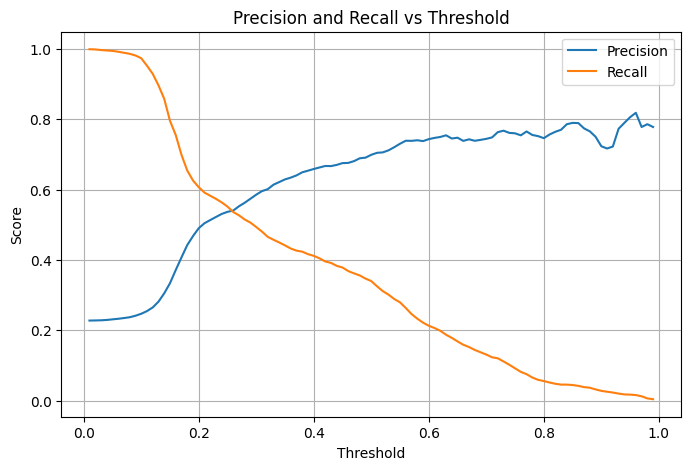

In [41]:
# plot of precision and recall against threshold
p = h_cl(theta_cl_1, X_cl_test_np).ravel()
y = y_cl_test

thresholds = np.arange(0.01, 1.0, 0.01) 
precisions = []
recalls = []

for thr in thresholds:
    y_pred = (p >= thr).astype(int)

    tp = np.sum((y_pred == 1) & (y == 1))
    fp = np.sum((y_pred == 1) & (y == 0))
    fn = np.sum((y_pred == 0) & (y == 1))

    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    precisions.append(prec)
    recalls.append(rec)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

If I try to maintain the precision to be greater than 0.5, the best threshold and recall are 0.21 and 0.59 respectively.

In [42]:
# maximze recall with a floor for precision
best_thr = 0.5
best_rec = 0.0
min_prec = 0.5   # choose a floor for precision (accuracy among positive prediction)

for thr in np.arange(0.01, 1.0, 0.01): # test for every 0.01
    y_pred = (p >= thr).astype(int)

    tp = np.sum((y_pred == 1) & (y == 1))
    fp = np.sum((y_pred == 1) & (y == 0))
    fn = np.sum((y_pred == 0) & (y == 1))

    if tp + fn == 0:
        rec = 0.0
    else:
        rec = tp / (tp + fn)

    if tp + fp == 0:
        prec = 0.0
    else:
        prec = tp / (tp + fp)

    if prec >= min_prec and rec > best_rec:
        best_rec = rec
        best_thr = thr

print(best_thr)
print(best_rec)

0.21000000000000002
0.5913404507710558


Secondly, traditional Conjugate Gradient method is applied. It took 2.5s and 138 loops to run, which is quite slow and the performance are close to the one using Newton Method. However, Newton method require inversing matrix, when the matrix are too large in size or multicollinearity exists, it will perform much worse.

In [43]:
theta_cl_2 = np.zeros(X_cl_train_np.shape[1])
te = 1e-6 # tolerance
max_iter = 1000 # maximum iterations
count = 0 # counter
h = h_cl(theta_cl_2, X_cl_train_np)
g = (1/X_cl_train_clean.shape[0]) * X_cl_train_np.T @ (h - y_cl_train)
d = -g # Q-orthonormal vector
sr = np.sqrt(h * (1 - h))
S = np.tile(sr[:, np.newaxis], (1, X_cl_train_np.shape[1]))
S = S * X_cl_train_np
H = (1/X_cl_train_clean.shape[0]) * S.T @ S
while (norm(g) > te) & (count < max_iter):
    g0 = g
    alpha = -(g.T@d)/(d.T@H@d)
    h = h_cl(theta_cl_2, X_cl_train_np)
    sr = np.sqrt(h * (1 - h))
    S = np.tile(sr[:, np.newaxis], (1, X_cl_train_np.shape[1]))
    S = S * X_cl_train_np
    H = (1/X_cl_train_clean.shape[0]) * S.T @ S
    theta_cl_2 = theta_cl_2 + alpha * d
    h = h_cl(theta_cl_2, X_cl_train_np)
    g = (1/X_cl_train_clean.shape[0]) * X_cl_train_np.T @ (h - y_cl_train)
    beta = (g.T@H@d)/(d.T@H@d)
    d = -g + beta * d
    count += 1
print(norm(g0))
print(count)
print(theta_cl_2)
y_cl_pred_train_2 = (h_cl(theta_cl_2, X_cl_train_np) >= 0.5)
y_cl_pred_test_2 = (h_cl(theta_cl_2, X_cl_test_np) >= 0.5)
tp_train_2 = np.sum((y_cl_pred_train_2 == 1) & (y_cl_train == 1))
tp_test_2 = np.sum((y_cl_pred_test_2 == 1) & (y_cl_test == 1))
fp_train_2 = np.sum((y_cl_pred_train_2 == 1) & (y_cl_train == 0))
fp_test_2 = np.sum((y_cl_pred_test_2 == 1) & (y_cl_test == 0))
tn_train_2 = np.sum((y_cl_pred_train_2 == 0) & (y_cl_train == 0))
tn_test_2 = np.sum((y_cl_pred_test_2 == 0) & (y_cl_test == 0))
fn_train_2 = np.sum((y_cl_pred_train_2 == 0) & (y_cl_train == 1))
fn_test_2 = np.sum((y_cl_pred_test_2 == 0) & (y_cl_test == 1))
recall_train_2 = tp_train_2/(tp_train_2 + fn_train_2)
recall_test_2 = tp_test_2/(tp_test_2 + fn_test_2)
print(recall_train_2)
print(recall_test_2)
dev_loss_train_2 = h_cl(theta_cl_2, X_cl_train_np).T@(X_actual_train['BILL_AMT1'] - X_actual_train['PAY_AMT1']).to_numpy() - y_cl_train.T@(X_actual_train['BILL_AMT1'] - X_actual_train['PAY_AMT1']).to_numpy() 
dev_loss_test_2 = h_cl(theta_cl_2, X_cl_test_np).T@(X_actual_test['BILL_AMT1'] - X_actual_test['PAY_AMT1']).to_numpy() - y_cl_test.T@(X_actual_test['BILL_AMT1'] - X_actual_test['PAY_AMT1']).to_numpy() 
print(dev_loss_train_2)
print(dev_loss_test_2)

1.1466077339895066e-06
138
[-1.28001561 -0.17176014 -0.11004707  0.03309854  0.66058872  0.03313721
  0.11335373  0.04006222  0.07707782  0.10182009 -0.11821451  0.2523429
 -0.00980704  0.05251568 -0.09714017 -0.2023496  -0.2594151   0.00429772
 -0.04436429 -0.02496305 -0.06483321  0.00281312 -0.01052862 -1.09071063
 -0.15963999 -0.0336489 ]
0.3271730300568643
0.3398576512455516
-182.3943021595478
2937485.674720362


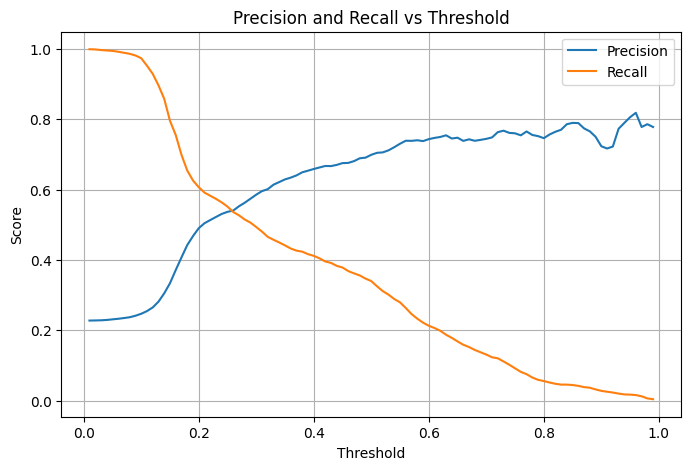

In [44]:
p = h_cl(theta_cl_2, X_cl_test_np).ravel()
y = y_cl_test

thresholds = np.arange(0.01, 1.0, 0.01)
precisions = []
recalls = []

for thr in thresholds:
    y_pred = (p >= thr).astype(int)

    tp = np.sum((y_pred == 1) & (y == 1))
    fp = np.sum((y_pred == 1) & (y == 0))
    fn = np.sum((y_pred == 0) & (y == 1))

    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    precisions.append(prec)
    recalls.append(rec)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

The best recall with minimum of 0.5 precision and its thereshold are also 0.55 and 0.24 respectively.

In [45]:
best_thr = 0.5
best_rec = 0.0
min_prec = 0.5   # choose a floor for precision (accuracy among positive prediction)

for thr in np.arange(0.01, 1.0, 0.01):
    y_pred = (p >= thr).astype(int)

    tp = np.sum((y_pred == 1) & (y == 1))
    fp = np.sum((y_pred == 1) & (y == 0))
    fn = np.sum((y_pred == 0) & (y == 1))

    if tp + fn == 0:
        rec = 0.0
    else:
        rec = tp / (tp + fn)

    if tp + fp == 0:
        prec = 0.0
    else:
        prec = tp / (tp + fp)

    if prec >= min_prec and rec > best_rec:
        best_rec = rec
        best_thr = thr

print(best_thr)
print(best_rec)

0.21000000000000002
0.5913404507710558


Thirdly, I have used the logistic regresion package with newton-cg solver. It took only 0.1s to run, which is quicker than my code, but the performance are close. 

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, precision_recall_curve
model_cl_1 = LogisticRegression(solver='newton-cg', penalty=None)
model_cl_1.fit(X_cl_train_clean, y_cl_train)
print(model_cl_1.coef_)
print(model_cl_1.intercept_)
y_cl_pred_train_3 = model_cl_1.predict(X_cl_train_clean) # get 0 or 1; use predict_proba to get 2 columns of array
y_cl_pred_test_3 = model_cl_1.predict(X_cl_test_clean)
print(recall_score(y_cl_train, y_cl_pred_train_3))
print(recall_score(y_cl_test, y_cl_pred_test_3))
dev_loss_train_3 = model_cl_1.predict_proba(X_cl_train_clean)[:, 1].T@(X_actual_train['BILL_AMT1'] - X_actual_train['PAY_AMT1']).to_numpy() - y_cl_train.T@(X_actual_train['BILL_AMT1'] - X_actual_train['PAY_AMT1']).to_numpy() 
dev_loss_test_3 = model_cl_1.predict_proba(X_cl_test_clean)[:, 1].T@(X_actual_test['BILL_AMT1'] - X_actual_test['PAY_AMT1']).to_numpy() - y_cl_test.T@(X_actual_test['BILL_AMT1'] - X_actual_test['PAY_AMT1']).to_numpy() 
print(dev_loss_train_3)
print(dev_loss_test_3)

[[-0.2081162  -0.12772327  0.03879686  0.68655599  0.00959604  0.10259036
   0.04509014  0.07941194  0.12540143 -0.06688368  0.20200526  0.00429318
  -0.0451661  -0.03864189 -0.17805165 -0.19044901 -0.03249148 -0.03603191
  -0.0362115  -0.03638824 -0.01537347 -0.05548223 -1.42028093 -0.14616417
  -0.1030361 ]]
[-1.24705443]
0.33481331987891016
0.33353474320241694
44585.78846359253
-1849590.426078096


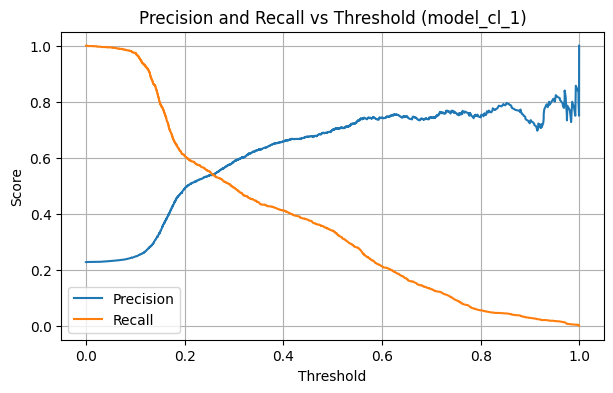

In [47]:
y_score = model_cl_1.predict_proba(X_cl_test_clean)[:, 1]  
precision, recall, thresholds = precision_recall_curve(y_cl_test, y_score)
thr = thresholds # threshold is 1 item shorter than precision and recall
prec_thr = precision[1:]   # align with thresholds
rec_thr  = recall[1:]
plt.figure(figsize=(7,4))
plt.plot(thr, prec_thr, label="Precision")
plt.plot(thr, rec_thr,  label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold (model_cl_1)")
plt.legend()
plt.grid(True)
plt.show()

The package provides more digits and accuracy on the best recall and threshold, but the values are still close to my models.

In [48]:
min_prec = 0.5
mask = prec_thr >= min_prec # condition

idx = np.argmax(rec_thr[mask])
best_thr = thr[mask][idx] # the first one fix to show the part of threshold that precision is greater than or equal to 0.5
best_rec = rec_thr[mask][idx] 
best_prec = prec_thr[mask][idx]
print(best_thr)
print(best_rec)

0.2057183751807855
0.597864768683274


Fourthly, I had used neural network with dense layers of 128, 64 and 32 neurons to build the classifier. This is a complicated model to capture the interaction of 26 features. I have used sgd to solve, relu as activation function, 0.001 regularization strength and maximum iterations of 1000 times. It took 4m 8.3s to train this complicated model. Althought it gives a better recall, the testing deviation of default loss is -4.7 million. It is a bad model to forecast the loss.

In [49]:
from sklearn.neural_network import MLPClassifier
clf_cl = MLPClassifier(hidden_layer_sizes=[128, 64, 32], activation='relu', solver='sgd', alpha = 0.001, max_iter=1000) # many hyperparameters can change
clf_cl.fit(X_cl_train_clean, y_cl_train)
y_cl_pred_train_4 = clf_cl.predict(X_cl_train_clean)
y_cl_pred_test_4 = clf_cl.predict(X_cl_test_clean)
print(recall_score(y_cl_train, y_cl_pred_train_4))
print(recall_score(y_cl_test, y_cl_pred_test_4))
dev_loss_train_4 = clf_cl.predict_proba(X_cl_train_clean)[:, 1].T@(X_actual_train['BILL_AMT1'] - X_actual_train['PAY_AMT1']).to_numpy() - y_cl_train.T@(X_actual_train['BILL_AMT1'] - X_actual_train['PAY_AMT1']).to_numpy() 
dev_loss_test_4 = clf_cl.predict_proba(X_cl_test_clean)[:, 1].T@(X_actual_test['BILL_AMT1'] - X_actual_test['PAY_AMT1']).to_numpy() - y_cl_test.T@(X_actual_test['BILL_AMT1'] - X_actual_test['PAY_AMT1']).to_numpy() 
print(dev_loss_train_4)
print(dev_loss_test_4)

0.5928107229894395
0.39798339264531435
-25455146.793939948
-4705817.909714222


The neural network package gives a symmetric recall and precision graph as the intersection of them are at 0.5. It means that the 2 variables are more controllable but adjusting the threshold. However, we forgone the opportunity to obtain both recall and precsion greater than 0.5.

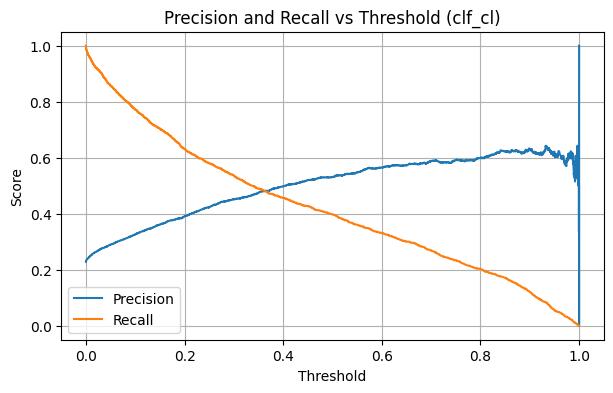

In [50]:
y_score = clf_cl.predict_proba(X_cl_test_clean)[:, 1]  
precision, recall, thresholds = precision_recall_curve(y_cl_test, y_score)
thr = thresholds
prec_thr = precision[1:]   # align with thresholds
rec_thr = recall[1:]
plt.figure(figsize=(7,4))
plt.plot(thr, prec_thr, label="Precision")
plt.plot(thr, rec_thr,  label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold (clf_cl)")
plt.legend()
plt.grid(True)
plt.show()

In [51]:
min_prec = 0.5
mask = prec_thr >= min_prec

idx = np.argmax(rec_thr[mask])
best_thr = thr[mask][idx]
best_rec = rec_thr[mask][idx]
best_prec = prec_thr[mask][idx]
print(best_thr)
print(best_rec)

0.4030391241257017
0.4555160142348754


Fifthly, I used the linear support vector machine to build the classifier. It took only 0.1s, which is quick. The recall is 0.31, not bad. Unfortunately, this model doesn't give the probability, we cannot calucalate the deviation of default loss.

In [52]:
from sklearn.svm import LinearSVC
linear_svm = LinearSVC(max_iter=10000).fit(X_cl_train_clean, y_cl_train)
y_cl_pred_train_5 = linear_svm.predict(X_cl_train_clean)
y_cl_pred_test_5 = linear_svm.predict(X_cl_test_clean)
print(recall_score(y_cl_train, y_cl_pred_train_5))
print(recall_score(y_cl_test, y_cl_pred_test_5))
print(precision_score(y_cl_train, y_cl_pred_train_5))
print(precision_score(y_cl_test, y_cl_pred_test_5))

0.3042242079610073
0.3125741399762752
0.6871559633027523
0.7054886211512718


Sixthly, I used a nonlinear SVM model with degree of polynomial at 3 and a higher class weight on the true label. This is the method to emphasis the recall. It took 43s, a bit long. It comes a good recall and precision score. However, we need to do trial and error to find the best combinations. So this model is not comprehensive and slow to try.

In [53]:
from sklearn.svm import SVC 
svm = SVC(kernel='poly',degree=3, class_weight={0: 1.0, 1: 3.0}).fit(X_cl_train_clean, y_cl_train) # higher weight on true gives better recall
y_cl_pred_train_6 = svm.predict(X_cl_train_clean)
y_cl_pred_test_6 = svm.predict(X_cl_test_clean)
print(recall_score(y_cl_train, y_cl_pred_train_6))
print(recall_score(y_cl_test, y_cl_pred_test_6))
print(precision_score(y_cl_train, y_cl_pred_train_6))
print(precision_score(y_cl_test, y_cl_pred_test_6))

0.5509748172217709
0.5201660735468565
0.5600743187448389
0.5383670963781461


Lastly, I tried xgboost, which is an ensemble tree method that I lack of understanding. It took 1.7s to run. The recall score is around 0.38, which is quite good. Unfortunately, the deviation of default loss is 2.7 million, the double of the best model. However, I can change the maximum depth and L2 regularization to balance these 2 metrics. This is something the other models cannot do.

In [54]:
from xgboost import XGBClassifier

xgb_model_cl = XGBClassifier(objective='binary:logistic',  
    n_estimators=300,             # Number of trees
    learning_rate=0.05,           # step size shrinkage
    max_depth=4,                  # tree depth
    reg_lambda=1.0,               # L2 regularization
    random_state=0)

xgb_model_cl.fit(X_cl_train_clean, y_cl_train)
y_cl_pred_train_7 = np.exp(xgb_model_cl.predict(X_cl_train_clean))
y_cl_pred_test_7 = np.exp(xgb_model_cl.predict(X_cl_test_clean))
y_cl_pred_train_7 = xgb_model_cl.predict(X_cl_train_clean) 
y_cl_pred_test_7 = xgb_model_cl.predict(X_cl_test_clean)
print(recall_score(y_cl_train, y_cl_pred_train_7))
print(recall_score(y_cl_test, y_cl_pred_test_7))
dev_loss_train_7 = xgb_model_cl.predict_proba(X_cl_train_clean)[:, 1].T@(X_actual_train['BILL_AMT1'] - X_actual_train['PAY_AMT1']).to_numpy() - y_cl_train.T@(X_actual_train['BILL_AMT1'] - X_actual_train['PAY_AMT1']).to_numpy() 
dev_loss_test_7 = xgb_model_cl.predict_proba(X_cl_test_clean)[:, 1].T@(X_actual_test['BILL_AMT1'] - X_actual_test['PAY_AMT1']).to_numpy() - y_cl_test.T@(X_actual_test['BILL_AMT1'] - X_actual_test['PAY_AMT1']).to_numpy() 
print(dev_loss_train_7)
print(dev_loss_test_7)

0.3984565393988627
0.37129300118623965
-1544106.0617257655
2745537.7863459885


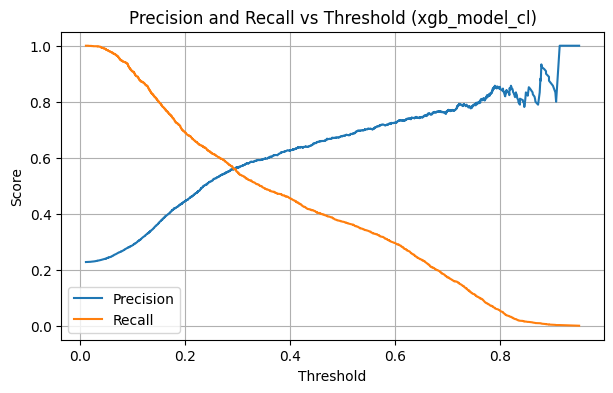

In [21]:
y_score = xgb_model_cl.predict_proba(X_cl_test_clean)[:, 1]  
precision, recall, thresholds = precision_recall_curve(y_cl_test, y_score)
thr = thresholds
prec_thr = precision[1:]   # align with thresholds
rec_thr = recall[1:]
plt.figure(figsize=(7,4))
plt.plot(thr, prec_thr, label="Precision")
plt.plot(thr, rec_thr,  label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold (xgb_model_cl)")
plt.legend()
plt.grid(True)
plt.show()

Other than the deviation of expected default loss, the xgboost model is quite good as it gives a recall of 0.64 at 0.24 threshold. It is the best among all the models.

In [22]:
min_prec = 0.5
mask = prec_thr >= min_prec

idx = np.argmax(rec_thr[mask])
best_thr = thr[mask][idx]
best_rec = rec_thr[mask][idx]
best_prec = prec_thr[mask][idx]
print(best_thr)
print(best_rec)

0.23587406
0.6370106761565836


In conclusion, the logistic regression in sklean package had the most comprehensive result. The neural network was slow, balanced the recall and precision, and poor in default loss estimation. Although SVM gave a good classification, no probability provided is hard to use. Lastly, xgboost can be used to get either good recall or good default loss by adjusting the hyperparameters.

The third task is dimension reduction of cardholder's data. I tried to reduce the 26 features of data into a lower dimension of matrix.

In [ ]:
X_pca = df.drop(columns=['ID', 'default.payment.next.month'])
X_pca = pd.get_dummies(X_pca, columns = ['EDUCATION', 'MARRIAGE'], dtype = float, drop_first=True)
X_pca.head()

,LIMIT_BAL,SEX,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,...,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_1.0,MARRIAGE_2.0
0,20000.0,1,24,2,2,0,0,0,0,3913.0,...,689.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,120000.0,1,26,0,2,0,0,0,2,2682.0,...,1000.0,1000.0,1000.0,0.0,2000.0,1.0,0.0,0.0,1.0,0.0
2,90000.0,1,34,0,0,0,0,0,0,29239.0,...,1500.0,1000.0,1000.0,1000.0,5000.0,1.0,0.0,0.0,1.0,0.0
3,50000.0,1,37,0,0,0,0,0,0,46990.0,...,2019.0,1200.0,1100.0,1069.0,1000.0,1.0,0.0,0.0,0.0,0.0
4,50000.0,0,57,0,0,0,0,0,0,8617.0,...,36681.0,10000.0,9000.0,689.0,679.0,1.0,0.0,0.0,0.0,0.0


The first method is to subtract the matrix by each column's mean and then do a singular value decomposition. I used the eigenvalues to plot the cumulative variance ratio, so as to determine the number of dimension to explain at least 95% of variance. It is found that the best dimension is 4 and this method has taken 0.2s only.

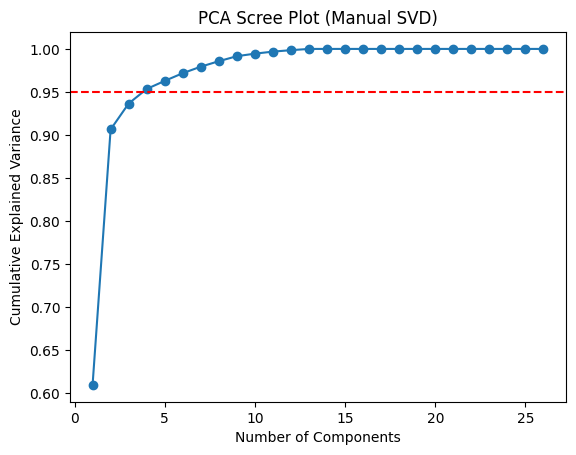

4


In [ ]:
X_pca_1 = X_pca.to_numpy() # change to numpy will speed up the svd time
X_m = X_pca_1 - X_pca_1.mean(axis = 0)
U, S, Vh = svd(X_m, full_matrices=False) # Vh is k*n in dimension (k is not larger than n and m)
V = Vh.T
X_pca_1 = X_m@V
eigenvalues = (S**2) / (X_m.shape[0] - 1)
explained_variance_ratio = eigenvalues / eigenvalues.sum() # variance ratio
cumulative_variance = np.cumsum(explained_variance_ratio) # cumulative ratio
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--')  # 95% threshold line
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot (Manual SVD)")
plt.show()

n_components = np.argmax(cumulative_variance >= 0.95) + 1 # minimum explained variance: 0.95
print(n_components)

In [ ]:
X_pca_1 = X_pca_1[:, :4] # set to 4 dimension
print(X_pca_1)

[[-1.66330762e+05 -7.51555179e+04  4.17805969e+02 -1.15065112e+02]
 [-1.13735708e+05  9.96112700e+03 -2.69967494e+03 -1.58438175e+03]
 [-9.81140458e+04 -3.33531267e+04  2.78888503e+03 -4.99389461e+03]
 ...
 [-1.40020023e+05 -7.75810471e+04 -2.61718880e+04 -7.51600266e+03]
 [-4.12585514e+04 -7.50040867e+04 -1.84245154e+04  4.45517816e+04]
 [-7.08076686e+04 -9.54891844e+04  1.40915542e+04  8.89640055e+03]]


On the other hand, using sklearn's PCA can do the above task by hust 2 lines of code and 0s. Hence, using package is much more efficient.

In [ ]:
from sklearn.decomposition import PCA
X_pca_2 = PCA().fit_transform(X_pca_1) # select the dimension by itself
X_pca_2

array([[-1.66330762e+05, -7.51555179e+04,  4.17805969e+02,
        -1.15065112e+02],
       [-1.13735708e+05,  9.96112700e+03, -2.69967494e+03,
        -1.58438175e+03],
       [-9.81140458e+04, -3.33531267e+04,  2.78888503e+03,
        -4.99389461e+03],
       ...,
       [-1.40020023e+05, -7.75810471e+04, -2.61718880e+04,
        -7.51600266e+03],
       [-4.12585514e+04, -7.50040867e+04, -1.84245154e+04,
         4.45517816e+04],
       [-7.08076686e+04, -9.54891844e+04,  1.40915542e+04,
         8.89640055e+03]], shape=(29655, 4))

The fourth task is to do a clustering on cardholder. This will allow me to divide customers into groups for analysis. First, I have used sklearn's kmeans package to do classification. The inertia and silhouette score plots are shown below. Since the silhouette score is highest at 2 clusters, I decide to split the data into 2. Noted that it cost 1m 39.2s to do the classification multiple times, it is really time-consuming.

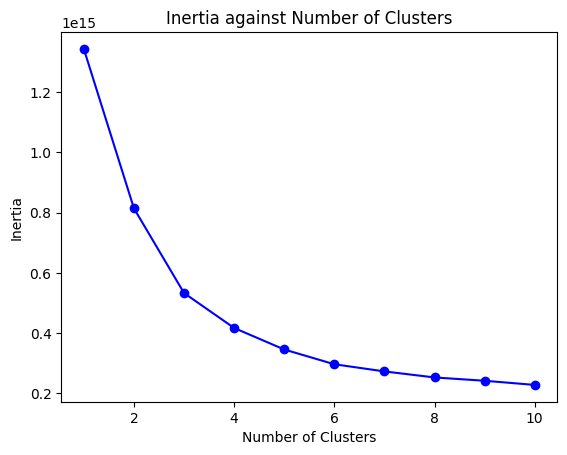

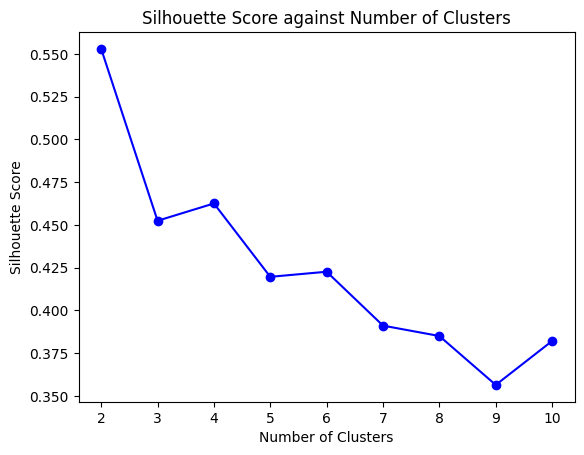

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score 
inertia = np.zeros(10) # save data from 1 cluster to 10
silhouette = np.zeros(9) # 2 cliusters to 10
kmeans = KMeans(n_clusters=1, n_init=5, random_state=0).fit(X_pca)
inertia[0] = kmeans.inertia_
for i in range(9):
    model = KMeans(n_clusters=i+2, n_init=5, random_state=0).fit(X_pca)
    inertia[i+1] = model.inertia_
    silhouette[i] = silhouette_score(X_pca, model.labels_)
plt.plot(range(1, 11), inertia, 'bo-')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Inertia against Number of Clusters")
plt.show()
plt.plot(range(2, 11), silhouette, 'bo-')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score against Number of Clusters")
plt.show()

I have calculated the mean of each features in each cluster. It seems to divide the cardholders into high-risk and low-risk groups. The first group has a low limit and pay the debit later, vice versa.

In [ ]:
kmeans = KMeans(n_clusters=2, n_init=5, random_state=0).fit(X_pca) 
cluster_mean = pd.DataFrame( # dataframe of means
    [X_pca[kmeans.labels_==0].mean(axis=0),
     X_pca[kmeans.labels_==1].mean(axis=0)],
    index=['label_0','label_1']
)
print(cluster_mean)

             LIMIT_BAL       SEX        AGE     PAY_0     PAY_2     PAY_3  \
label_0  148924.671464  0.608026  35.255749  0.363384  0.326737  0.314847   
label_1  283615.776853  0.574749  36.798385  0.326890  0.296795  0.257646   

            PAY_4     PAY_5     PAY_6      BILL_AMT1  ...      PAY_AMT2  \
label_0  0.268695  0.229115  0.234277   28563.822708  ...   4292.123201   
label_1  0.214583  0.190604  0.195498  190646.625642  ...  15879.826278   

             PAY_AMT3      PAY_AMT4      PAY_AMT5      PAY_AMT6  EDUCATION_2  \
label_0   3929.581704   3757.588548   3738.406954   4061.554873     0.473874   
label_1  13120.693173  11503.251040  11369.928799  12147.658429     0.468314   

         EDUCATION_3  EDUCATION_4  MARRIAGE_1.0  MARRIAGE_2.0  
label_0     0.171582     0.004028      0.538407      0.011577  
label_1     0.129679     0.004894      0.499144      0.005383  

[2 rows x 26 columns]


I tried to use this clustering method to see how it accurates to predict default directly. From the confusion matrix, the group with lower limit has 23% cases of default, while higher limit group has 19% cases of default. The accuracy of this "model" is 69%. Although statistical criterion recommended me to select k to be 2, I can also try more clusters to generate more business insights.

In [ ]:
from sklearn.metrics import confusion_matrix
con = confusion_matrix(y_cl, kmeans.labels_) # use kmeans labels to predict default risk (fortunately 0 and 1 are match)
print(con)
print((con[0,0]+con[1,1])/(con.sum()))

[[19726  3319]
 [ 5842   768]]
0.6910807620974541


To do a quick comparision, I tried the best-performed classification model, the Logistic Regression package. In the condition that I did not drop out correlated columns and standardized the data, the accuracy is around 82%, higher than clustering itself.

In [54]:
model_cl_best = LogisticRegression(solver='newton-cg', penalty=None)
model_cl_best.fit(X_pca, y_cl)
y_cl_pred_best = (model_cl_best.predict(X_pca) > 0.5).astype(int)
con_1 = confusion_matrix(y_cl, y_cl_pred_best)
print(con_1)
print((con_1[0,0]+con_1[1,1])/(con_1.sum()))

[[22070   975]
 [ 4506  2104]]
0.8151745068285281


c:\Users\85251\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
c:\Users\85251\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\optimize.py:100: LineSearchWarning: The line search algorithm did not converge
  ret = line_search_wolfe2(
c:\Users\85251\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\optimize.py:319: ConvergenceWarning: newton-cg failed to converge at loss = 0.4491887164808555. Increase the number of iterations.
  warnings.warn(


Secondly, I tried RBSCAN with minimum 5 data in a cluster. The plot below has shown the distance of the fifth-nearest data. By elbow method, epsilon should be chosen around 5. This checking consumes 0.8s, much quicker than the kmeans method.

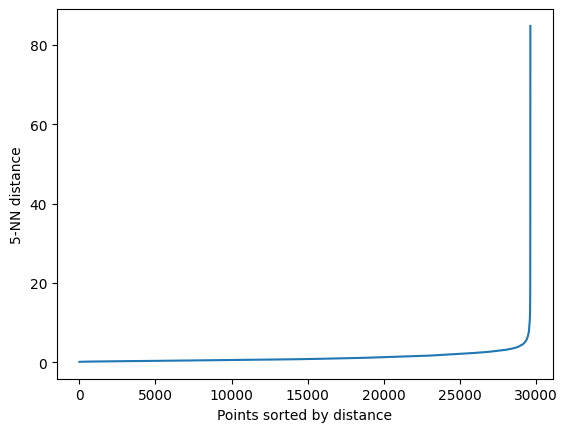

In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
X_pca_scaled = StandardScaler().fit_transform(X_pca) # scale the data first
neigh = NearestNeighbors(n_neighbors=5) # min_samples = 5
neigh.fit(X_pca_scaled) 
distances, indices = neigh.kneighbors(X_pca_scaled) # distance of the fifth clostest neighbor
distances = np.sort(distances[:,4])  # 4 = min_samples (5) -1
plt.plot(distances)
plt.ylabel("5-NN distance")
plt.xlabel("Points sorted by distance")
plt.show()


Then, I trained the model and see the distributions of data. There are some anomalies and most data belong to group 0. In addition, it took 40.9s to process. Although it is slightly quicker, the extremely uneven distribution encourged me to choose kmeans method.

In [58]:
from sklearn.cluster import DBSCAN 

dbscan = DBSCAN(eps=5, min_samples=5) 
dbscan.fit(X_pca_scaled) 
labels = dbscan.labels_
cluster_counts = pd.Series(labels).value_counts().sort_index()
print(cluster_counts)

-1      261
 0    28945
 1      305
 2      115
 3       29
Name: count, dtype: int64
